## Cross-Sample Motif Analysis

This notebook analyzes 3-mer frequency distributions across multiple samples. The goal is to compare the motif profiles between samples for different genomic feature sets.

The process is as follows:
1. **Load Data**: Load all `_EM.csv` files, representing different biological samples.
2. **Restructure Data**: For each of the four genomic feature sets (TFBS, Biomart, CpG Islands, Genome-wide), create a master DataFrame where rows are motifs and columns are samples.
3. **Normalize**: Convert the raw frequencies in each column to relative frequencies (probability distributions) by dividing by the column sum.
4. **Analyze & Visualize**: For each feature set, calculate and plot:
    - A **Spearman Correlation Matrix** to measure the monotonic relationship between sample profiles.
    - A **Jensen-Shannon Divergence Matrix** to measure the similarity between the probability distributions of the sample profiles.

In [1]:
import os
from glob import glob

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.spatial.distance import jensenshannon
from tqdm import tqdm

### 1. Data Loading and Restructuring

In [2]:
# Define the directories for the different feature sets
dirs = ["aggregated_tfbs", "biomart", "cpg_islands_ucsc_hgtables", "genome_wide"]
dir_titles = ["Aggregated TFBS", "Biomart Promoters", "CpG Islands", "Genome-Wide"]

# Get a list of all sample files from one of the directories
motif_files = glob("./extracted_features/aggregated_tfbs/*_EM.csv")

# Extract sample names from the file paths (e.g., 'sample1_EM.csv' -> 'sample1')
sample_names = [os.path.basename(f).replace("_EM.csv", "") for f in motif_files]

# This dictionary will hold the four master DataFrames, one for each feature set.
region_dfs = {d: [] for d in dirs}

# Loop through each sample to collect its data for all regions
for sample_name, file_path in tqdm(zip(sample_names, motif_files, strict=False), total=len(sample_names), desc="Loading Samples"):
    for dir_name in dirs:
        # Construct the path to the corresponding file in the other directories
        specific_file_path = f"./extracted_features/{dir_name}/{os.path.basename(file_path)}"

        if os.path.exists(specific_file_path):
            # Read the s3 column from the csv
            temp_df = pd.read_csv(specific_file_path, index_col=0)[["s3"]]
            # Rename the column to the sample name
            temp_df.rename(columns={"s3": sample_name}, inplace=True)
            # Append the sample's data to the correct region list
            region_dfs[dir_name].append(temp_df)

# Concatenate the lists of DataFrames into four master DataFrames
for dir_name in dirs:
    if region_dfs[dir_name]:
        # axis=1 joins the dataframes horizontally, aligning on the 'motif' index
        region_dfs[dir_name] = pd.concat(region_dfs[dir_name], axis=1)
    else:
        # Handle case where a directory might be empty
        region_dfs[dir_name] = pd.DataFrame()

print("Data loading and restructuring complete.")
print(f"Found {len(sample_names)} samples.")

Loading Samples:  33%|███▎      | 3/9 [00:00<00:00, 19.69it/s]

Loading Samples: 100%|██████████| 9/9 [00:00<00:00, 23.71it/s]

Data loading and restructuring complete.
Found 9 samples.


### 2. Cross-Sample Comparison for Each Feature Set


--- Analyzing: Aggregated TFBS ---


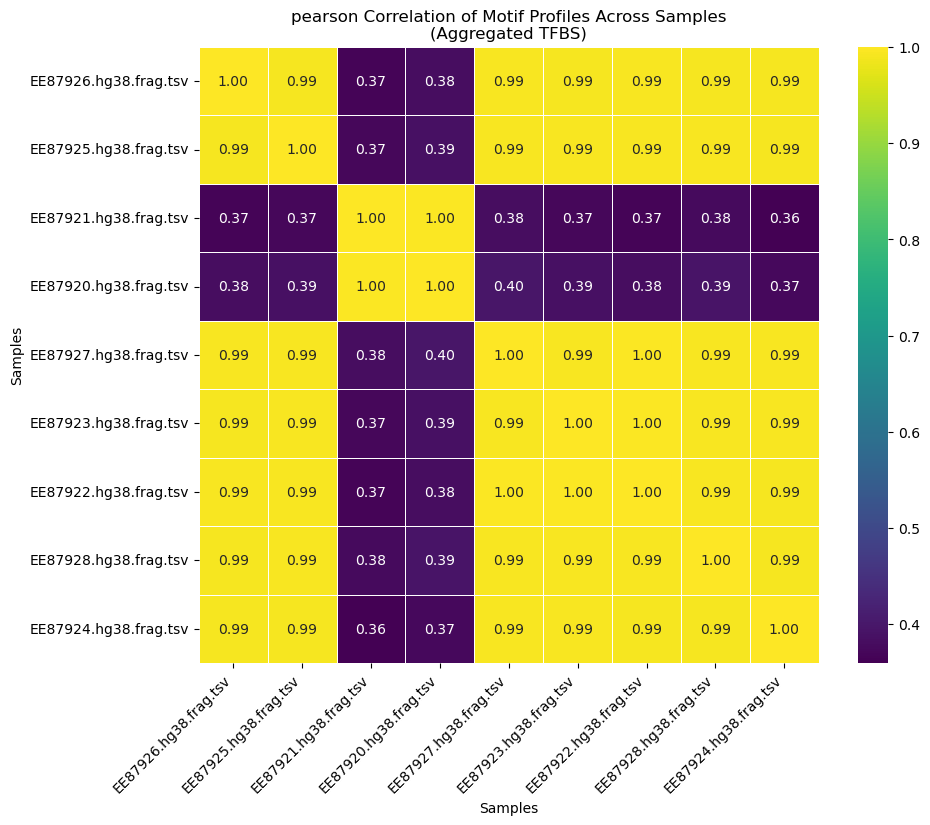

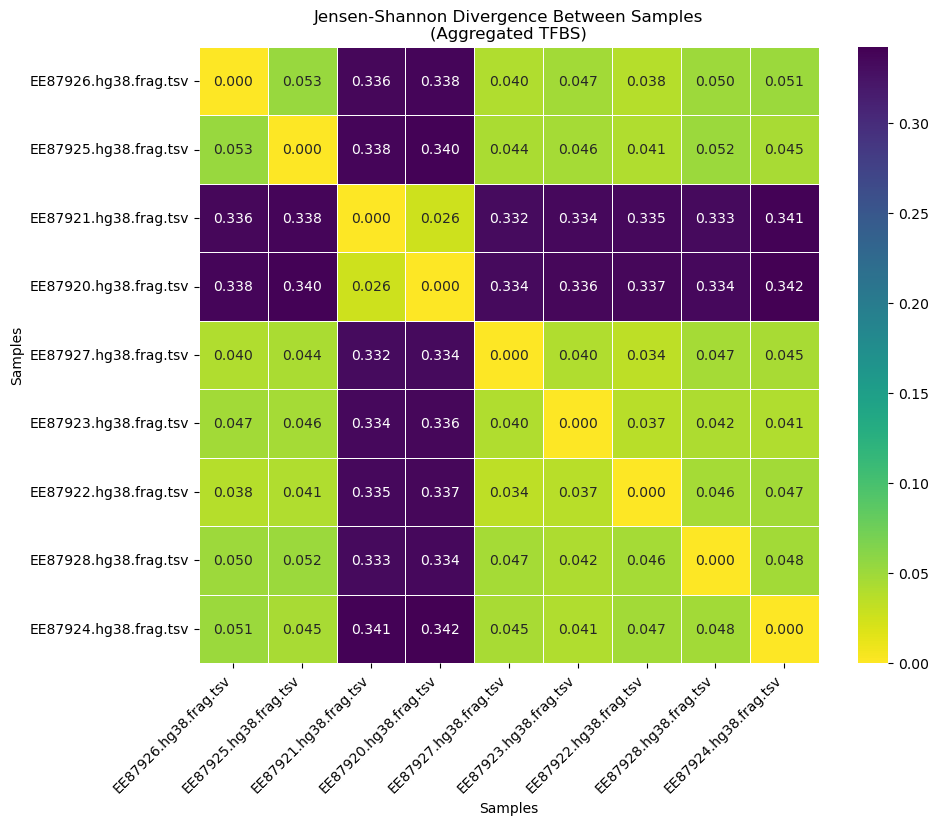


--- Analyzing: Biomart Promoters ---


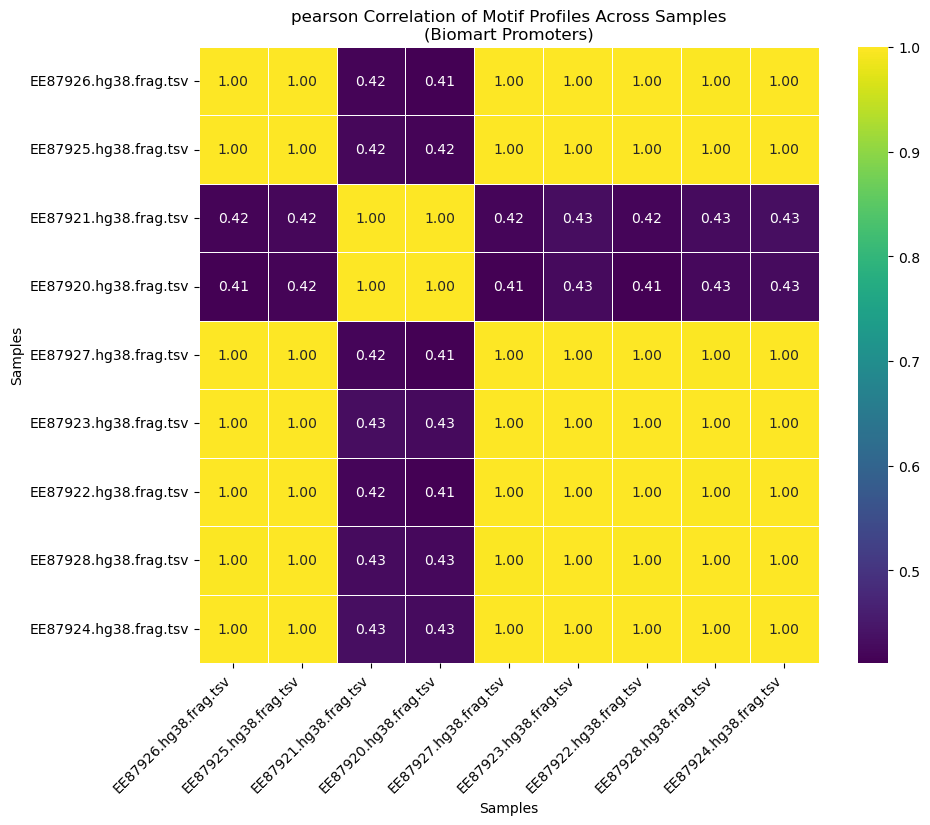

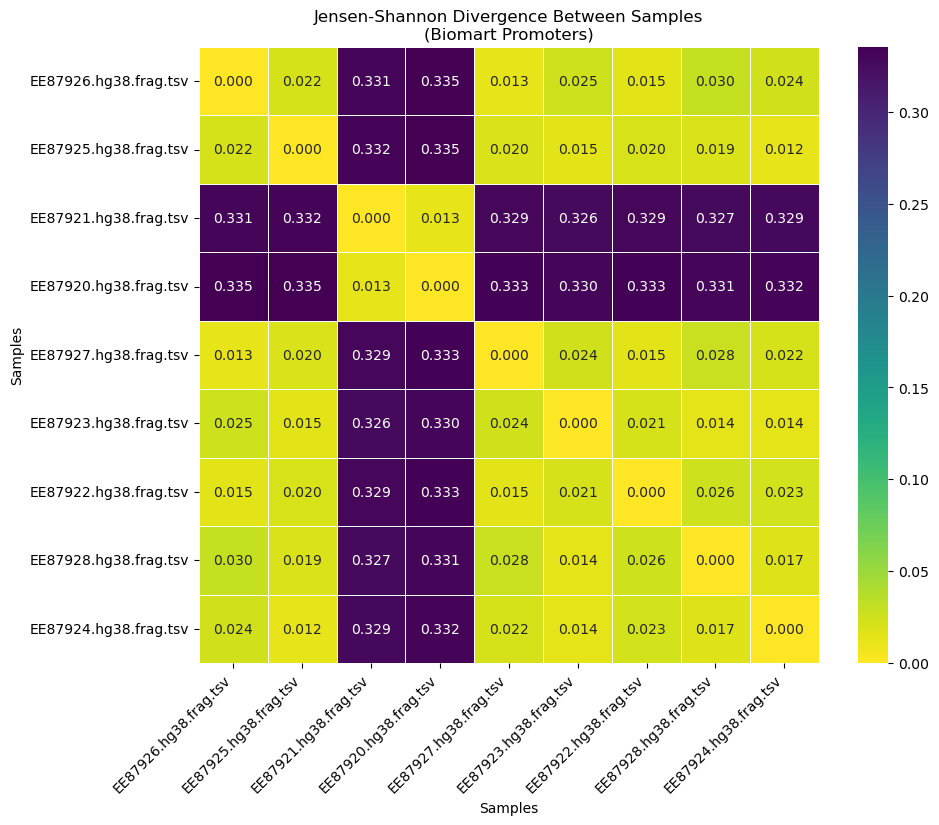


--- Analyzing: CpG Islands ---


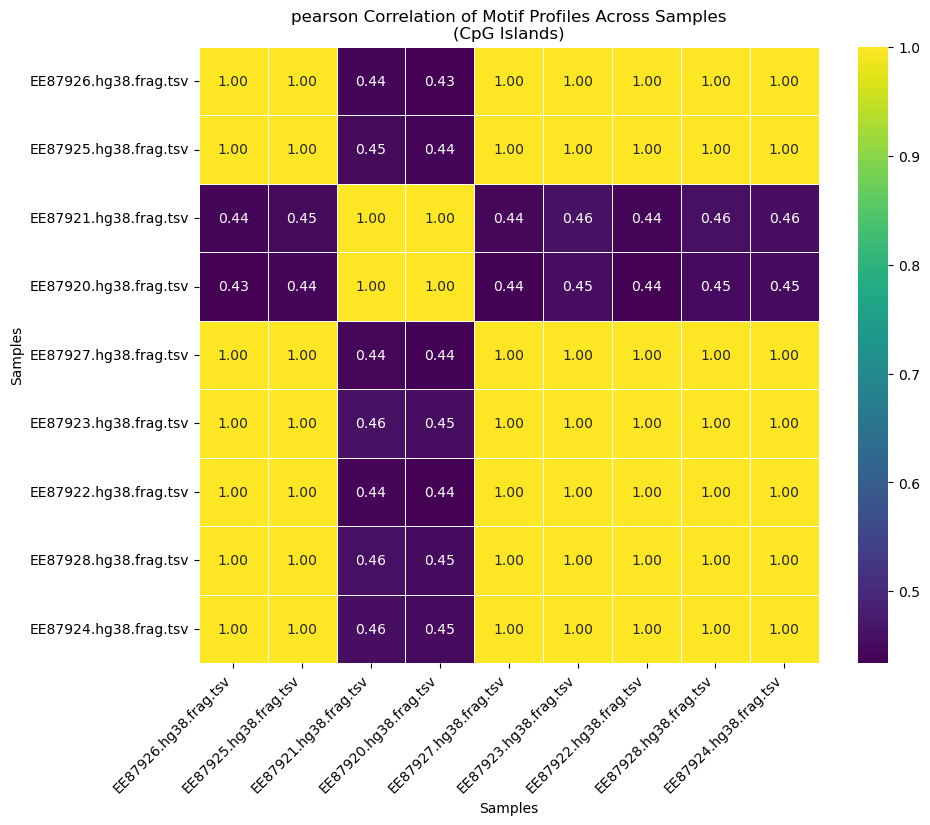

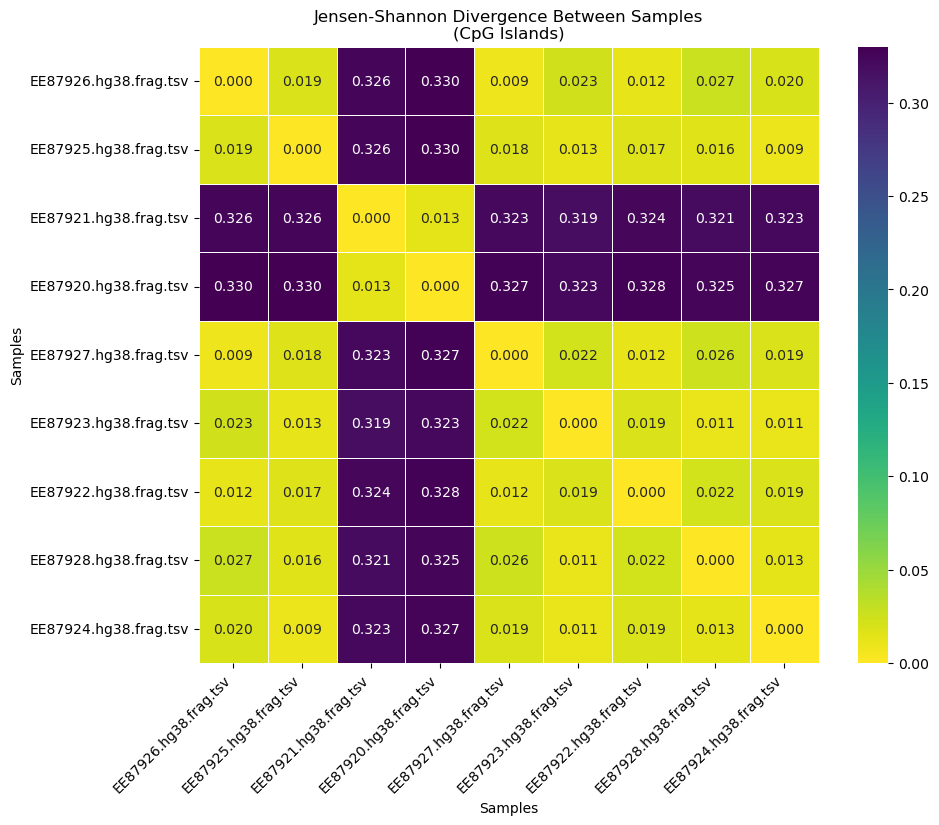


--- Analyzing: Genome-Wide ---


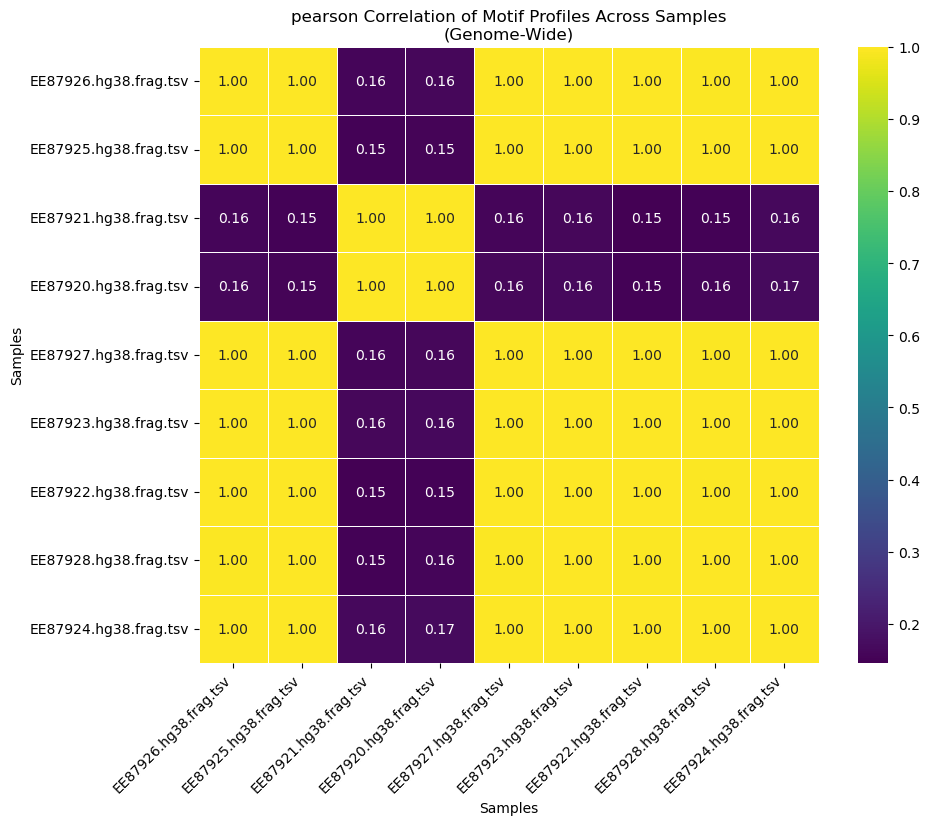

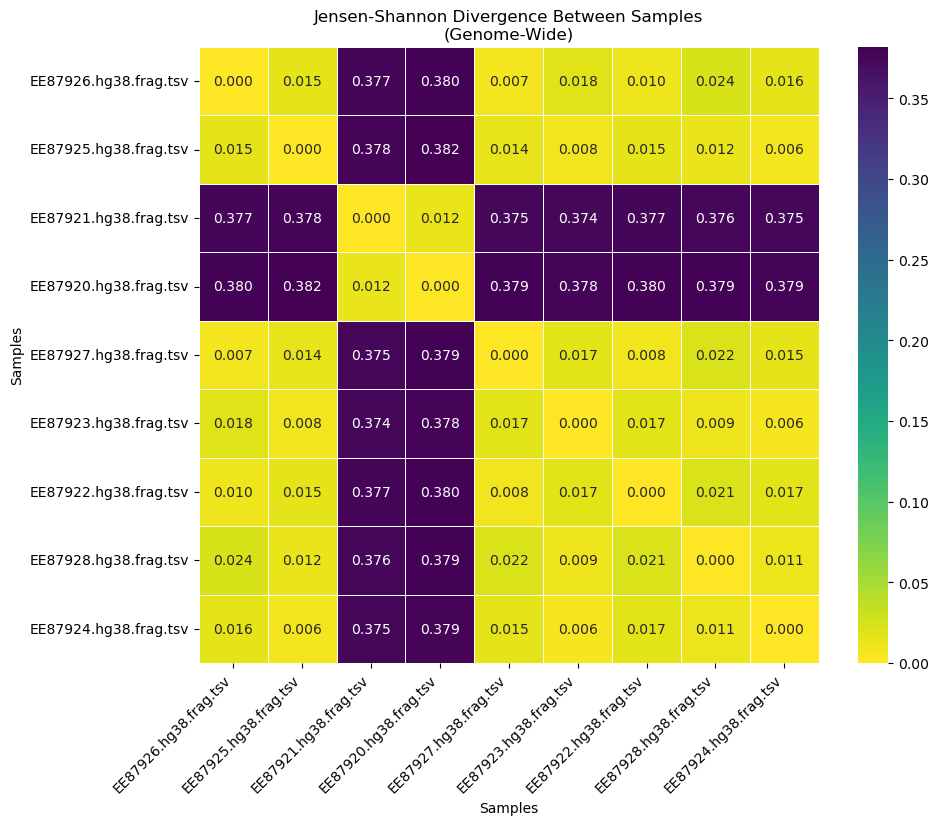

In [3]:
# Loop through each feature set DataFrame to perform the analysis
for dir_name, title in zip(dirs, dir_titles, strict=False):
    df = region_dfs[dir_name]

    if df.empty:
        print(f"\nSkipping '{title}' as no data was found.")
        continue

    print(f"\n--- Analyzing: {title} ---")

    # --- A. Normalize Data ---
    # Divide all columns by their sum to get relative frequencies (probability distributions)
    df_relative = df.div(df.sum(axis=0), axis=1)

    # --- B. pearson Correlation ---
    correlation_matrix = df_relative.corr(method="pearson")

    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="viridis", linewidths=0.5)
    plt.title(f"pearson Correlation of Motif Profiles Across Samples\n({title})")
    plt.xlabel("Samples")
    plt.ylabel("Samples")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.show()

    # --- C. Jensen-Shannon Divergence ---
    # This measures the similarity between the probability distributions of the samples.
    # A value of 0 means identical, a higher value means more divergent.
    js_divergence_matrix = pd.DataFrame(index=df_relative.columns, columns=df_relative.columns, dtype=float)

    for col1 in df_relative.columns:
        for col2 in df_relative.columns:
            js_divergence_matrix.loc[col1, col2] = jensenshannon(df_relative[col1], df_relative[col2])

    plt.figure(figsize=(10, 8))
    # We use a reversed colormap (e.g., 'viridis_r') because lower JS divergence means higher similarity.
    sns.heatmap(js_divergence_matrix, annot=True, fmt=".3f", cmap="viridis_r", linewidths=0.5)
    plt.title(f"Jensen-Shannon Divergence Between Samples\n({title})")
    plt.xlabel("Samples")
    plt.ylabel("Samples")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.show()